# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Saira Nashwa Ramadhani]
- **Email:** [saira.ramadhani@gmail.com]
- **ID Dicoding:** [CDCC284D6X1859]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Produk kategori apa yang menghasilkan total revenue tertinggi pada tahun 2017 hingga 2018?
- **Pertanyaan 2:** Apakah terdapat korelasi antara biaya pengiriman (freight value) dengan skor ulasan (review score) pelanggan untuk seluruh pesanan yang diselesaikan sepanjang tahun 2017 hingga 2018?

## Import Semua Packages/Library yang Digunakan

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

## Data Wrangling

### Gathering Data

In [2]:
!unzip E-commerce-public-dataset.zip -d E-commerce-public-dataset

Archive:  E-commerce-public-dataset.zip
  inflating: E-commerce-public-dataset/E-Commerce Public Dataset/customers_dataset.csv  
  inflating: E-commerce-public-dataset/E-Commerce Public Dataset/geolocation_dataset.csv  
 extracting: E-commerce-public-dataset/E-Commerce Public Dataset/New Text Document.txt  
  inflating: E-commerce-public-dataset/E-Commerce Public Dataset/order_items_dataset.csv  
  inflating: E-commerce-public-dataset/E-Commerce Public Dataset/order_payments_dataset.csv  
  inflating: E-commerce-public-dataset/E-Commerce Public Dataset/order_reviews_dataset.csv  
  inflating: E-commerce-public-dataset/E-Commerce Public Dataset/orders_dataset.csv  
  inflating: E-commerce-public-dataset/E-Commerce Public Dataset/product_category_name_translation.csv  
  inflating: E-commerce-public-dataset/E-Commerce Public Dataset/products_dataset.csv  
  inflating: E-commerce-public-dataset/E-Commerce Public Dataset/sellers_dataset.csv  


#### Load df ...

In [8]:
customers_df = pd.read_csv('E-commerce-public-dataset/E-Commerce Public Dataset/customers_dataset.csv')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [9]:
geolocaion_df = pd.read_csv('E-commerce-public-dataset/E-Commerce Public Dataset/geolocation_dataset.csv')
geolocaion_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [10]:
order_items_df = pd.read_csv('E-commerce-public-dataset/E-Commerce Public Dataset/order_items_dataset.csv')
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [11]:
order_payments_df = pd.read_csv('E-commerce-public-dataset/E-Commerce Public Dataset/order_payments_dataset.csv')
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [12]:
order_payments_df = pd.read_csv('E-commerce-public-dataset/E-Commerce Public Dataset/order_payments_dataset.csv')
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [13]:
order_reviews_df = pd.read_csv('E-commerce-public-dataset/E-Commerce Public Dataset/order_reviews_dataset.csv')
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [14]:
orders_df = pd.read_csv('E-commerce-public-dataset/E-Commerce Public Dataset/orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [15]:
product_category_name_translation_df = pd.read_csv('E-commerce-public-dataset/E-Commerce Public Dataset/product_category_name_translation.csv')
product_category_name_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [16]:
products_df = pd.read_csv('E-commerce-public-dataset/E-Commerce Public Dataset/products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [17]:
sellers_df = pd.read_csv('E-commerce-public-dataset/E-Commerce Public Dataset/customers_dataset.csv')
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:** (Opsional)
- Mengumpulkan semua informasi yang diperlukan dari sumber dataset "E-Commerce Public Dataset". Memuat data pesanan (orders), detail item (order items), data produk, ulasan pelanggan, hingga tabel terjemahan kategori produk. Hal ini dilakukan karena informasi yang dibutuhkan untuk menjawab pertanyaan bisnis tersebar di beberapa tabel yang berbeda.

### Assessing Data

#### Identifying ... problem

In [23]:
print("Info Orders:\n", orders_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
Info Orders:
 None


In [24]:
print("\nMissing Values di Orders:\n", orders_df.isna().sum())


Missing Values di Orders:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [25]:
print("\nJumlah Dupllikasi di Orders:", orders_df.duplicated().sum())


Jumlah Dupllikasi di Orders: 0


In [26]:
print("\nMissing Values di Products:\n", products_df.isna().sum())


Missing Values di Products:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


**Steps to Take:**
- Mengubah tipe data kolom tanggal menjadi datetime.
- Menangani missing values pada nama kategori produk.
- Menggabungkan tabel (merging) untuk analisis lebih lanjut.

**Insight:** (Opsional)
- Adanya missing values pada kolom tanggal pengiriman dan nama kategori produk.
- Kesalahan tipe data pada kolom timestamp yang terbaca sebagai objek (string).
- Nama kategori produk masih menggunakan Bahasa Portugis yang perlu diterjemahkan agar analisis lebih mudah dipahami.

### Cleaning Data

#### Fixing ... problem

In [37]:
# Mengubah kolom waktu menjadi datetime
datetime_columns = ["order_purchase_timestamp", "order_delivered_customer_date"]
for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

In [38]:
# Merging tabel order item, products, dan product category name translation
main_df = pd.merge(order_items_df, products_df, on="product_id", how="left")
main_df = pd.merge(main_df, product_category_name_translation_df, on="product_category_name", how="left")

In [39]:
# Merging tabel orders dan review
main_df = pd.merge(main_df, orders_df, on="order_id", how="left")
main_df = pd.merge(main_df, order_reviews_df, on="order_id", how="left")

In [41]:
# Dropping data dengan product category name yang kosong
main_df.dropna(subset=['product_category_name_english'], inplace=True)

In [42]:
main_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,97ca439bc427b48bc1cd7177abe71365,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,0c5b33dea94867d1ac402749e5438e8b,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,940144190dcba6351888cafa43f3a3a5,5.0,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59


**Insight:** (Opsional)
- Mengubah tipe data kolom tanggal menjadi datetime.
- Menangani missing values pada nama kategori produk.
- Menggabungkan tabel (merging) untuk analisis lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore ...

In [33]:
# Mencari total revenue untuk setiap kategori produk
category_revenue_df = main_df.groupby("product_category_name_english").agg({
    "price": "sum"
}).sort_values(by="price", ascending=False).reset_index()

print("10 Kategori Produk dengan Revenue Tertinggi (2017-2018):")
print(category_revenue_df.head(10))

10 Kategori Produk dengan Revenue Tertinggi (2017-2018):
  product_category_name_english       price
0                 health_beauty  1263138.54
1                 watches_gifts  1206075.33
2                bed_bath_table  1050936.61
3                sports_leisure   993656.51
4         computers_accessories   919640.54
5               furniture_decor   736282.47
6                    cool_stuff   637258.51
7                    housewares   634542.60
8                          auto   594363.10
9                  garden_tools   486432.45


In [35]:
# Rata-rata skor ulasan berdasarkan kelompok biaya pengiriman
correlation_value = main_df['freight_value'].corr(main_df['review_score'])

print(f"Nilai korelasi antara Freight Value dan Review Score: {correlation_value}")

Nilai korelasi antara Freight Value dan Review Score: -0.037307179949523914


In [36]:
# Rata-rata review score untuk pesanan dengan ongkir mahal vs murah
main_df['freight_group'] = pd.cut(main_df['freight_value'], bins=[0, 20, 50, 100, 500], labels=['Murah', 'Sedang', 'Mahal', 'Sangat Mahal'])
freight_impact_df = main_df.groupby('freight_group', observed=True).agg({
    'review_score': 'mean'
}).reset_index()

print("\nRata-rata Review Score berdasarkan kelompok Biaya Ongkir:")
print(freight_impact_df)


Rata-rata Review Score berdasarkan kelompok Biaya Ongkir:
  freight_group  review_score
0         Murah      4.070013
1        Sedang      3.952494
2         Mahal      3.904468
3  Sangat Mahal      3.783206


**Insight:** (Opsional)
- Analisis Revenue: Melakukan pengelompokan (grouping) berdasarkan kategori produk untuk melihat kontribusi pendapatan terbesar.
- Analisis Kepuasan: Menghitung korelasi antara biaya pengiriman dengan skor ulasan. Saya juga melakukan teknik binning (pengelompokan) pada biaya ongkir untuk melihat perbedaan rata-rata rating secara lebih jelas.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_27840/1818374252.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


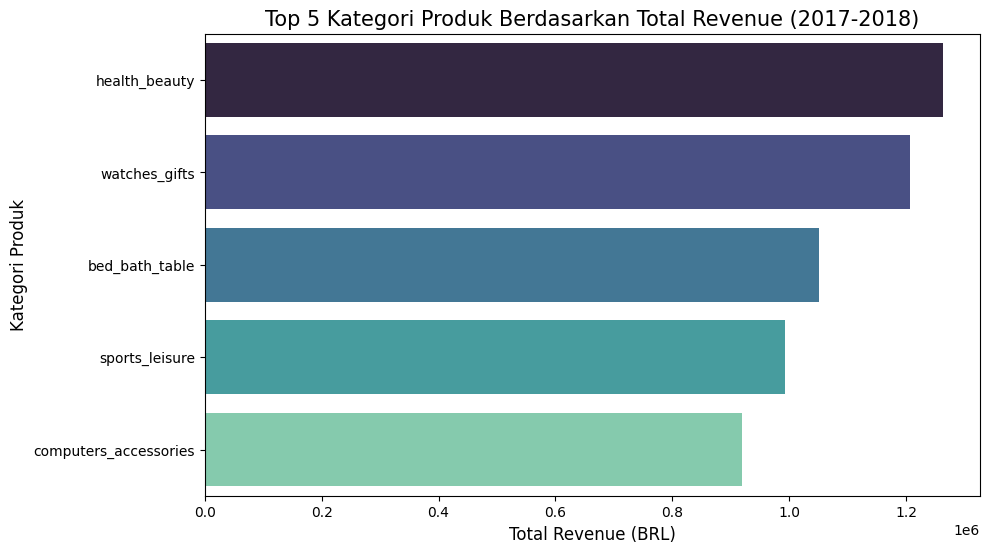

In [51]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="price",
    y="product_category_name_english",
    data=category_revenue_df.head(5),
    palette="mako"
)
plt.title("Top 5 Kategori Produk Berdasarkan Total Revenue (2017-2018)", fontsize=15)
plt.xlabel("Total Revenue (BRL)", fontsize=12)
plt.ylabel("Kategori Produk", fontsize=12)
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_27840/824785376.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


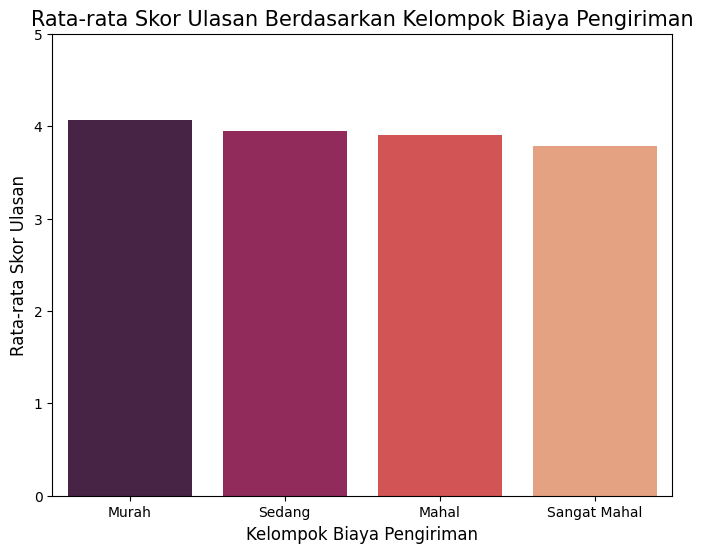

In [58]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x="freight_group",
    y="review_score",
    data=freight_impact_df,
    palette="rocket"
)
plt.ylim(0, 5) # Biar skala ratingnya jelas dari 0-5
plt.title("Rata-rata Skor Ulasan Berdasarkan Kelompok Biaya Pengiriman", fontsize=15)
plt.xlabel("Kelompok Biaya Pengiriman", fontsize=12)
plt.ylabel("Rata-rata Skor Ulasan", fontsize=12)
plt.show()

**Insight:** (Opsional)
- Bar plot digunakan untuk membandingkan performa antar kategori produk secara kontras.
- Visualisasi pengaruh ongkir terhadap rating menunjukkan tren yang jelas bahwa biaya logistik yang tinggi berisiko menurunkan skor ulasan pelanggan.

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kategori produk "health_beauty" merupakan penyumbang revenue terbesar bagi e-commerce selama tahun 2017-2018, diikuti oleh kategori "watches_gifts" dan "bed_bath_table". Hal ini menunjukkan bahwa produk kecantikan, kesehatan, dan perlengkapan rumah tangga adalah komoditas utama yang menggerakkan nilai transaksi pada e-commerce ini.
- **Conclusion pertanyaan 2:** Adanya penurunan rata-rata skor ulasan seiring dengan meningkatnya biaya pengiriman. Kelompok pengiriman "Murah" memiliki rata-rata rating tertinggi (di atas 4.0), sedangkan kelompok "Sangat Mahal" memiliki rating yang paling rendah (mendekati 3.8). Hal ini membuktikan bahwa beban biaya pengiriman yang tinggi berpotensi menurunkan tingkat kepuasan pelanggan secara keseluruhan.

**Rekomendasi Action Item:**
- Optimalisasi Logistik: Melakukan evaluasi atau kerja sama baru dengan mitra pengiriman untuk menekan biaya ongkir, terutama pada kategori produk yang populer namun memiliki biaya pengiriman "Mahal" atau "Sangat Mahal".

- Strategi Subsidi Ongkir: Menerapkan program subsidi ongkir atau free shipping dengan syarat minimal belanja pada kategori top revenue (seperti health_beauty) untuk menjaga skor ulasan tetap tinggi.

In [54]:
main_df.to_csv("main_data.csv", index=False)

In [57]:
files.download('main_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>